In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


In [34]:
def add_calendar_features(df):
    out = df.copy()
    dt = out["period_start_dt"]

    out["year"] = dt.dt.year.astype("Int64")
    out["month"] = dt.dt.month.astype("Int64")
    out["week"] = dt.dt.isocalendar().week.astype("Int64")
    out["quarter"] = dt.dt.quarter.astype("Int64")
    out["is_month_start"] = dt.dt.is_month_start.astype("Int64")
    out["is_month_end"] = dt.dt.is_month_end.astype("Int64")
    out["is_year_end"] = dt.dt.is_year_end.astype("Int64")

    return out


In [35]:
train_df = add_calendar_features(train_df)
test_df = add_calendar_features(test_df)

train_lag = train_df.sort_values(["product_rk","store_location_rk","period_start_dt"]).copy()
train_lag["_demand"] = train_lag["demand"]

lag_list = [1,2,3,4,5,8,13,26,52]
win_list = [4,8,13]

for lag in lag_list:
    train_lag[f"lag_{lag}"] = train_lag.groupby(["product_rk","store_location_rk"])["_demand"].shift(lag)

for win in win_list:
    train_lag[f"roll_mean_{win}"] = (
        train_lag.groupby(["product_rk","store_location_rk"])["_demand"]
        .shift(1).rolling(win).mean()
    )

train_model_df = train_lag[train_lag["demand"].notna()].copy()


In [15]:
test_df = test_df[test_df["id"].isin(submission_template["id"])].copy()
test_df.shape, test_df["period_start_dt"].value_counts()


((1200, 5),
 period_start_dt
 2019-02-12    240
 2019-09-12    240
 Name: count, dtype: int64)

In [16]:
drop_if_exists = [c for c in ["Unnamed: 0", "NUM_CONSULTANT", "PROMO2_FLAG"] if c in train_df.columns]
train_df = train_df.drop(columns=drop_if_exists)

train_df["product_rk"] = pd.to_numeric(train_df["product_rk"], errors="coerce").astype("Int64")
train_df["store_location_rk"] = pd.to_numeric(train_df["store_location_rk"], errors="coerce").astype("Int64")

test_df["product_rk"] = pd.to_numeric(test_df["product_rk"], errors="coerce").astype("Int64")
test_df["store_location_rk"] = pd.to_numeric(test_df["store_location_rk"], errors="coerce").astype("Int64")

train_df.shape, test_df.shape


((35344, 8), (1200, 5))

In [17]:
needed_stores = set(train_df["store_location_rk"].dropna().astype(int).tolist()) | set(test_df["store_location_rk"].dropna().astype(int).tolist())

store_df["STORE_LOCATION_RK"] = pd.to_numeric(store_df["STORE_LOCATION_RK"], errors="coerce").astype("Int64")
store_used = store_df[store_df["STORE_LOCATION_RK"].isin(list(needed_stores))].copy()

constant_cols = [c for c in store_used.columns if store_used[c].nunique(dropna=False) == 1]
store_used = store_used.drop(columns=constant_cols)

if "STORE_LOCATION_LVL_RK4" in store_used.columns and "STORE_LOCATION_LVL_RK3" in store_used.columns:
    if (store_used["STORE_LOCATION_LVL_RK4"].fillna("") == store_used["STORE_LOCATION_LVL_RK3"].fillna("")).all():
        store_used = store_used.drop(columns=["STORE_LOCATION_LVL_RK4"])

store_used = store_used.rename(columns={
    "STORE_LOCATION_RK": "store_location_rk",
    "STORE_LOCATION_LVL_RK3": "store_level_3",
})

store_feature_cols = ["store_location_rk"]
if "store_level_3" in store_used.columns:
    store_feature_cols.append("store_level_3")

hashed_cols = [c for c in store_used.columns if c.startswith("STORE_LOCATION_ATTRIB") and c.endswith("_hashing")]
hashed_cols = [c for c in hashed_cols if store_used[c].nunique(dropna=False) > 1]
store_feature_cols += hashed_cols

store_features = store_used[store_feature_cols].copy()
store_features.shape, store_features.head(3)


((41, 12),
     store_location_rk store_level_3    STORE_LOCATION_ATTRIB2_hashing  \
 32                309           203  1B208496FEF79DB5BE9F374BF65865E6   
 40                317           189  1B208496FEF79DB5BE9F374BF65865E6   
 78                355            54  1B208496FEF79DB5BE9F374BF65865E6   
 
       STORE_LOCATION_ATTRIB3_hashing    STORE_LOCATION_ATTRIB4_hashing  \
 32  B5A368A9689D233843CB7A34709BD45B  1D870936A2C35AA44CB0CF9B6210FB74   
 40  9B9B954D2D5B0F1C5B0B129DF8DED631  04E5A06E3993F6C9A4BFDEF278636ED5   
 78  39ED0D2B753268FD16E042087A244FDC  04E5A06E3993F6C9A4BFDEF278636ED5   
 
       STORE_LOCATION_ATTRIB8_hashing    STORE_LOCATION_ATTRIB9_hashing  \
 32  F2D475B39396781ED7F2D76E648AFAE4  D2C50D70FBCF0A56020B70626BF2FB2C   
 40  19517FD4F1E15806B405B9D730EEADCE  B2581C791DBB8894BFDCFB66B60A17ED   
 78  9BE4F7DC711A2F182743CC0C7DB1EA0C  B2581C791DBB8894BFDCFB66B60A17ED   
 
      STORE_LOCATION_ATTRIB10_hashing   STORE_LOCATION_ATTRIB11_hashing  \
 32  410E878

In [18]:
train_df = train_df.merge(store_features, on="store_location_rk", how="left")
test_df = test_df.merge(store_features, on="store_location_rk", how="left")

train_df.shape, test_df.shape


((35344, 19), (1200, 16))

In [19]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = out["period_start_dt"]

    out["year"] = dt.dt.year.astype("Int64")
    out["month"] = dt.dt.month.astype("Int64")

    iso = dt.dt.isocalendar()
    out["week"] = iso.week.astype("Int64")

    out["dayofweek"] = dt.dt.dayofweek.astype("Int64")
    out["quarter"] = dt.dt.quarter.astype("Int64")

    out["is_month_start"] = dt.dt.is_month_start.astype("Int64")
    out["is_month_end"] = dt.dt.is_month_end.astype("Int64")
    out["is_year_end"] = dt.dt.is_year_end.astype("Int64")

    return out


In [20]:
tmp = train_df.copy()

tmp["PROMO1_FLAG"] = pd.to_numeric(tmp.get("PROMO1_FLAG"), errors="coerce")
tmp["AUTORIZATION_FLAG"] = pd.to_numeric(tmp.get("AUTORIZATION_FLAG"), errors="coerce")
tmp["PRICE_REGULAR"] = pd.to_numeric(tmp.get("PRICE_REGULAR"), errors="coerce")
tmp["PRICE_AFTER_DISC"] = pd.to_numeric(tmp.get("PRICE_AFTER_DISC"), errors="coerce")

tmp["promo_any"] = (tmp["PROMO1_FLAG"].fillna(0) > 0).astype(int)
tmp["discount_rate"] = (1.0 - (tmp["PRICE_AFTER_DISC"] / tmp["PRICE_REGULAR"])).replace([np.inf, -np.inf], np.nan)
tmp["discount_rate"] = tmp["discount_rate"].clip(lower=0, upper=0.95)

group_cols = ["product_rk", "store_location_rk"]

group_stats = tmp[tmp["demand"].notna()].groupby(group_cols).agg(
    promo_any_rate=("promo_any", "mean"),
    auth_rate=("AUTORIZATION_FLAG", "mean"),
    regular_price_median=("PRICE_REGULAR", "median"),
    discount_rate_mean=("discount_rate", "mean"),
).reset_index()

global_stats = {
    "promo_any_rate": float(group_stats["promo_any_rate"].mean()),
    "auth_rate": float(group_stats["auth_rate"].mean()),
    "regular_price_median": float(group_stats["regular_price_median"].median()),
    "discount_rate_mean": float(group_stats["discount_rate_mean"].mean()),
}

train_df = train_df.merge(group_stats, on=group_cols, how="left")
test_df = test_df.merge(group_stats, on=group_cols, how="left")

for c, v in global_stats.items():
    train_df[c] = train_df[c].fillna(v)
    test_df[c] = test_df[c].fillna(v)

train_df[["promo_any_rate","auth_rate","regular_price_median","discount_rate_mean"]].head(3)


,promo_any_rate,auth_rate,regular_price_median,discount_rate_mean
0,0.0,0.907464,750.0,0.062286
1,0.0,0.907464,750.0,0.062286
2,0.0,0.907464,750.0,0.062286


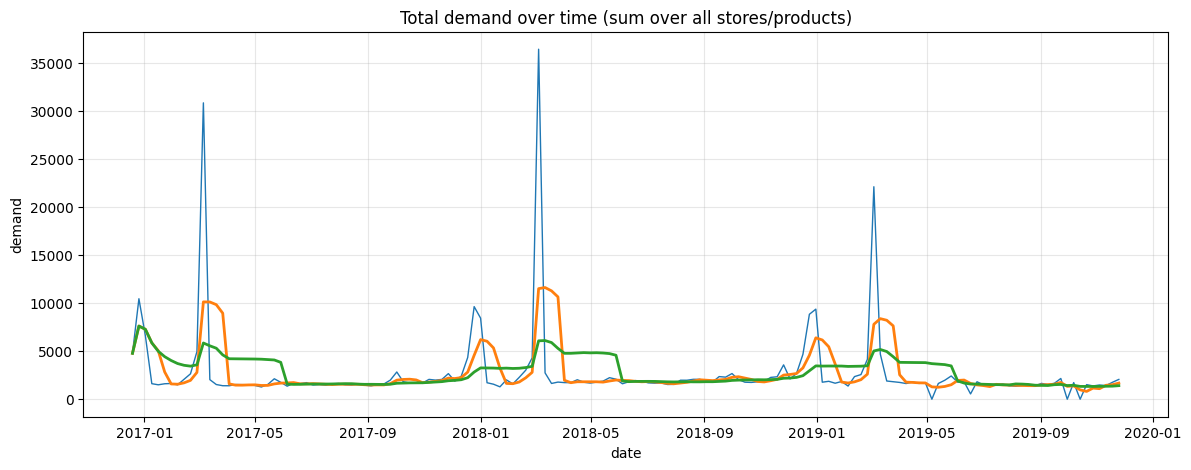

In [21]:
train_known = train_df[train_df["demand"].notna()].copy()

ts_total = train_known.groupby("period_start_dt")["demand"].sum().sort_index()
ts_ma4 = ts_total.rolling(4, min_periods=1).mean()
ts_ma13 = ts_total.rolling(13, min_periods=1).mean()

plt.figure(figsize=(14,5))
plt.plot(ts_total.index, ts_total.values, linewidth=1)
plt.plot(ts_ma4.index, ts_ma4.values, linewidth=2)
plt.plot(ts_ma13.index, ts_ma13.values, linewidth=2)
plt.title("Total demand over time (sum over all stores/products)")
plt.xlabel("date")
plt.ylabel("demand")
plt.grid(True, alpha=0.3)
plt.show()


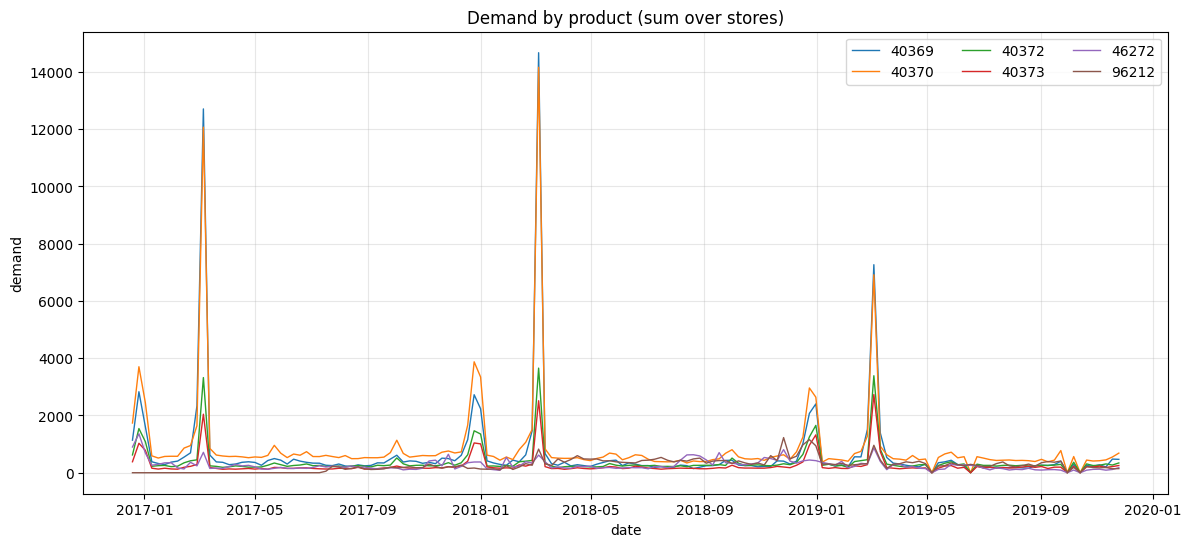

In [22]:
ts_by_product = train_known.groupby(["period_start_dt","product_rk"])["demand"].sum().reset_index()
pivot_prod = ts_by_product.pivot(index="period_start_dt", columns="product_rk", values="demand").fillna(0).sort_index()

plt.figure(figsize=(14,6))
for c in pivot_prod.columns:
    plt.plot(pivot_prod.index, pivot_prod[c].values, linewidth=1, label=str(c))
plt.title("Demand by product (sum over stores)")
plt.xlabel("date")
plt.ylabel("demand")
plt.grid(True, alpha=0.3)
plt.legend(ncol=3)
plt.show()


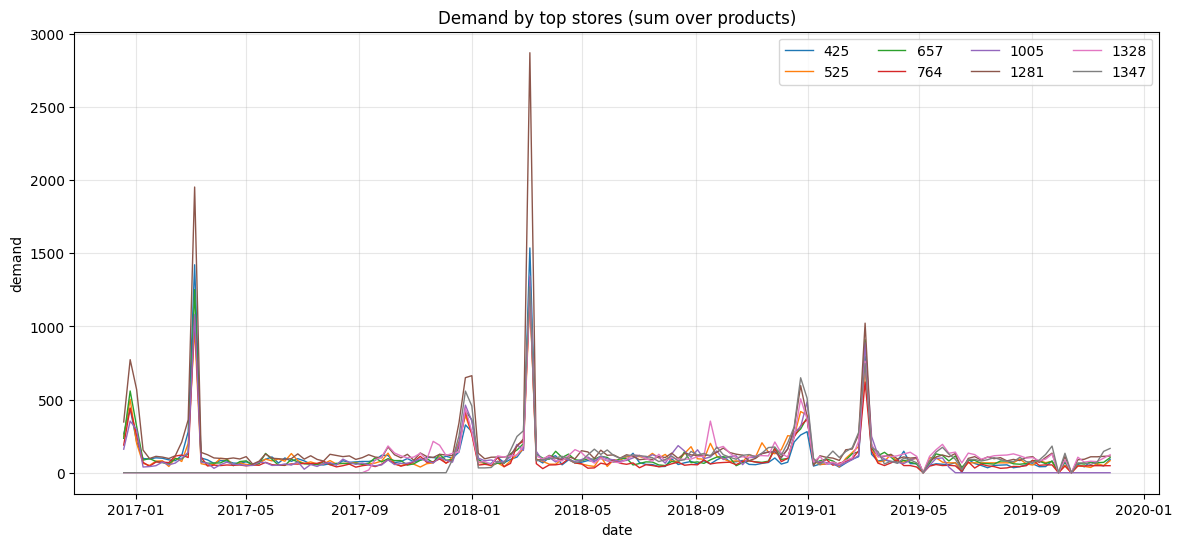

In [23]:
store_totals = train_known.groupby("store_location_rk")["demand"].sum().sort_values(ascending=False)
top_stores = store_totals.head(8).index.tolist()

ts_by_store = train_known[train_known["store_location_rk"].isin(top_stores)].groupby(
    ["period_start_dt","store_location_rk"]
)["demand"].sum().reset_index()

pivot_store = ts_by_store.pivot(index="period_start_dt", columns="store_location_rk", values="demand").fillna(0).sort_index()

plt.figure(figsize=(14,6))
for c in pivot_store.columns:
    plt.plot(pivot_store.index, pivot_store[c].values, linewidth=1, label=str(c))
plt.title("Demand by top stores (sum over products)")
plt.xlabel("date")
plt.ylabel("demand")
plt.grid(True, alpha=0.3)
plt.legend(ncol=4)
plt.show()


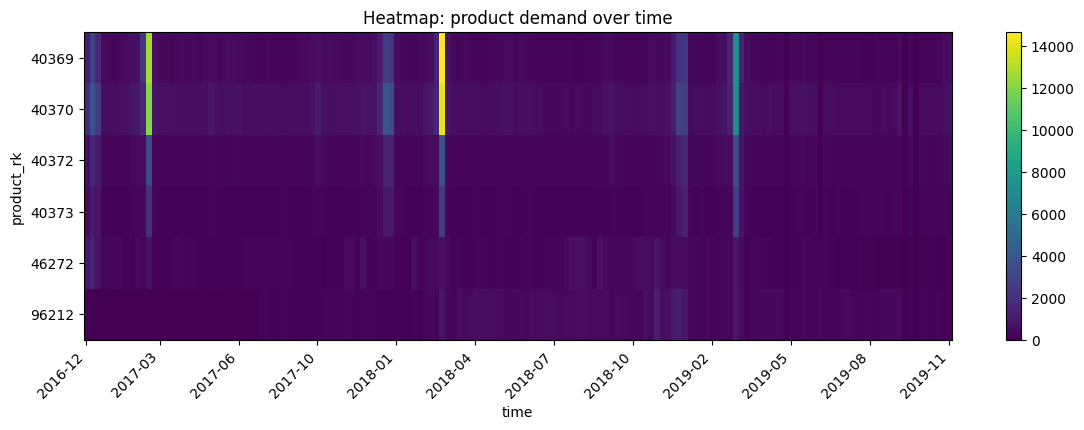

In [24]:
hm = pivot_prod.copy()
hm = hm.loc[hm.index.sort_values()]

z = hm.values.T
plt.figure(figsize=(14,4))
plt.imshow(z, aspect="auto", interpolation="nearest")
plt.yticks(range(len(hm.columns)), [str(c) for c in hm.columns])
xt = np.linspace(0, len(hm.index)-1, 12).astype(int)
plt.xticks(xt, [hm.index[i].strftime("%Y-%m") for i in xt], rotation=45, ha="right")
plt.title("Heatmap: product demand over time")
plt.xlabel("time")
plt.ylabel("product_rk")
plt.colorbar()
plt.show()


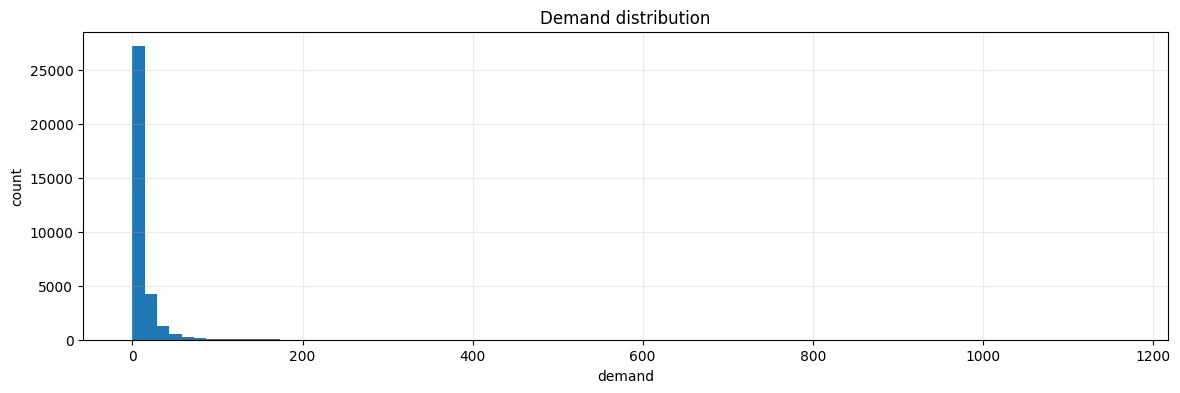

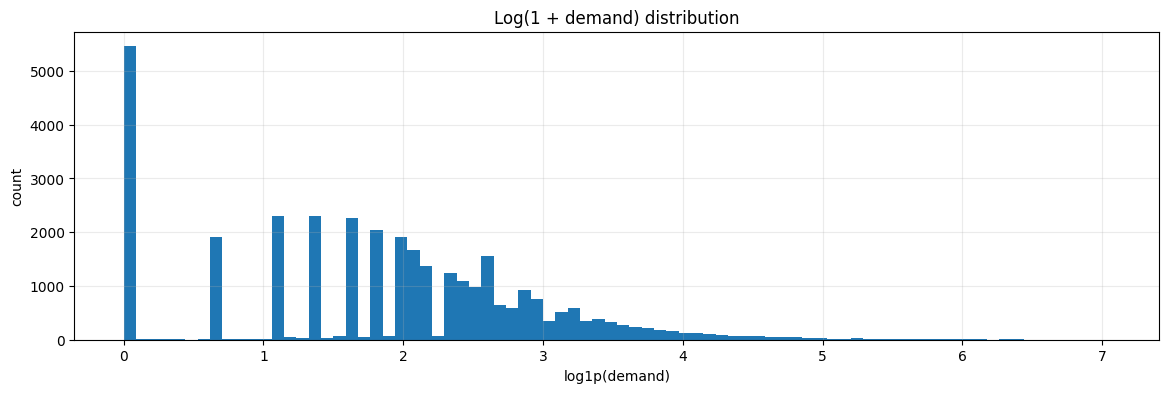

In [25]:
x = train_known["demand"].astype(float).values

plt.figure(figsize=(14,4))
plt.hist(x, bins=80)
plt.title("Demand distribution")
plt.xlabel("demand")
plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(14,4))
plt.hist(np.log1p(x), bins=80)
plt.title("Log(1 + demand) distribution")
plt.xlabel("log1p(demand)")
plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.show()


In [26]:
all_df = pd.concat(
    [train_df.assign(is_test=0), test_df.assign(is_test=1)],
    ignore_index=True,
    sort=False
).sort_values(["product_rk","store_location_rk","period_start_dt"]).reset_index(drop=True)

keys = ["product_rk","store_location_rk"]
all_df["_demand_known"] = all_df["demand"]
all_df["group_mean"] = all_df.groupby(keys)["_demand_known"].transform("mean")
all_df["group_median"] = all_df.groupby(keys)["_demand_known"].transform("median")

lag_list = [1,2,3,4,5,8,13,26,52]
win_list = [4,8,13]

for lag in lag_list:
    all_df[f"lag_{lag}"] = all_df.groupby(keys)["_demand_known"].shift(lag)

for win in win_list:
    all_df[f"roll_mean_{win}"] = all_df.groupby(keys)["_demand_known"].transform(lambda x: x.shift(1).rolling(win).mean())
    all_df[f"roll_std_{win}"] = all_df.groupby(keys)["_demand_known"].transform(lambda x: x.shift(1).rolling(win).std())

train_rows = all_df[(all_df["is_test"] == 0) & (all_df["demand"].notna())].copy()
train_rows.shape


(34144, 43)

In [27]:
cutoff = train_rows["period_start_dt"].max() - pd.Timedelta(weeks=12)
train_part = train_rows[train_rows["period_start_dt"] <= cutoff].copy()
val_part = train_rows[train_rows["period_start_dt"] > cutoff].copy()

cat_cols = ["product_rk","store_location_rk"]
if "store_level_3" in all_df.columns:
    cat_cols.append("store_level_3")
cat_cols += [c for c in store_features.columns if c.endswith("_hashing")]
cat_cols = [c for c in cat_cols if c in train_part.columns]

drop_cols = {"demand","period_start_dt","is_test","_demand_known","PROMO1_FLAG","PRICE_REGULAR","PRICE_AFTER_DISC","AUTORIZATION_FLAG","id"}
num_cols = [c for c in train_part.columns if c not in cat_cols and c not in drop_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
    ],
    remainder="drop",
)

model = Pipeline([("prep", preprocessor), ("model", Ridge(alpha=2.0))])

X_train = train_part[cat_cols + num_cols]
y_train = np.log1p(train_part["demand"].astype(float))
model.fit(X_train, y_train)

val_pred = np.expm1(model.predict(val_part[cat_cols + num_cols]))
val_pred = np.maximum(val_pred, 0)

rmse = float(np.sqrt(mean_squared_error(val_part["demand"].astype(float), val_pred)))
rmse


7.237041722181043

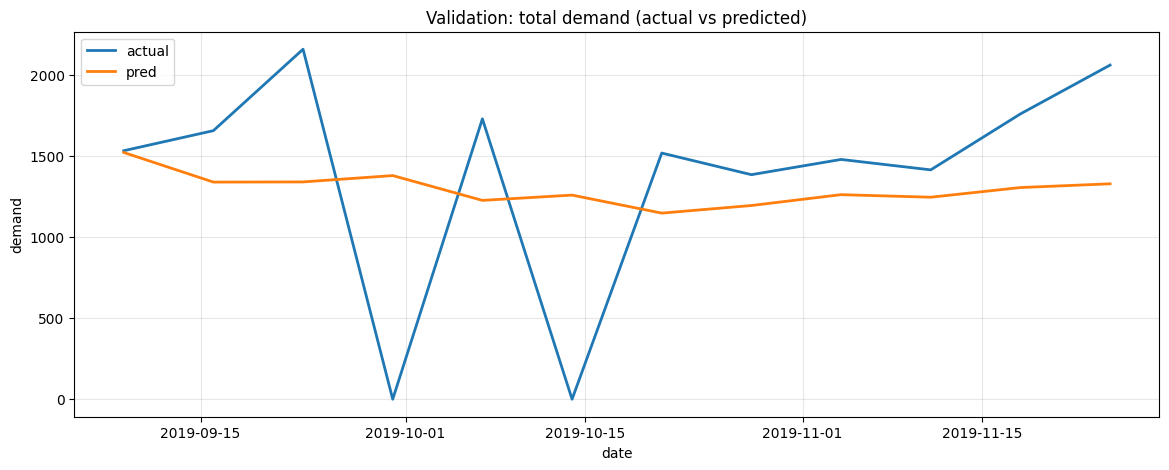

In [28]:
val_plot = val_part[["period_start_dt","demand"]].copy()
val_plot["pred"] = val_pred
val_plot = val_plot.groupby("period_start_dt")[["demand","pred"]].sum().sort_index()

plt.figure(figsize=(14,5))
plt.plot(val_plot.index, val_plot["demand"].values, linewidth=2, label="actual")
plt.plot(val_plot.index, val_plot["pred"].values, linewidth=2, label="pred")
plt.title("Validation: total demand (actual vs predicted)")
plt.xlabel("date")
plt.ylabel("demand")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [29]:
forecast_df = pd.concat(
    [train_df.assign(is_test=0), test_df.assign(is_test=1)],
    ignore_index=True,
    sort=False
).sort_values(["product_rk","store_location_rk","period_start_dt"]).reset_index(drop=True)

forecast_df["_demand_known"] = forecast_df["demand"]
forecast_df["group_mean"] = forecast_df.groupby(keys)["_demand_known"].transform("mean")
forecast_df["group_median"] = forecast_df.groupby(keys)["_demand_known"].transform("median")

for lag in lag_list:
    forecast_df[f"lag_{lag}"] = np.nan
for win in win_list:
    forecast_df[f"roll_mean_{win}"] = np.nan
    forecast_df[f"roll_std_{win}"] = np.nan

train_known = train_df[train_df["demand"].notna()].copy()
group_cap = (train_known.groupby(keys)["demand"].max() * 1.5).to_dict()
global_cap = float(train_known["demand"].max() * 1.5)
global_mean = float(train_known["demand"].mean())

demand_filled = forecast_df["demand"].astype(float).to_numpy()

for (p, s), idxs in forecast_df.groupby(keys, sort=False).indices.items():
    cap = float(group_cap.get((p, s), global_cap))
    cap_log = float(np.log1p(cap))
    history = []
    for idx in idxs:
        for lag in lag_list:
            forecast_df.at[idx, f"lag_{lag}"] = history[-lag] if len(history) >= lag else np.nan
        for win in win_list:
            if len(history) >= win:
                w = np.array(history[-win:], dtype=float)
                forecast_df.at[idx, f"roll_mean_{win}"] = float(np.mean(w))
                forecast_df.at[idx, f"roll_std_{win}"] = float(np.std(w, ddof=1)) if win > 1 else 0.0
            else:
                forecast_df.at[idx, f"roll_mean_{win}"] = np.nan
                forecast_df.at[idx, f"roll_std_{win}"] = np.nan

        if not np.isfinite(demand_filled[idx]):
            row = forecast_df.loc[[idx], cat_cols + num_cols]
            yhat_log = float(model.predict(row)[0])
            yhat_log = float(np.clip(yhat_log, 0.0, cap_log))
            pred = float(np.expm1(yhat_log))
            if not np.isfinite(pred):
                pred = float(forecast_df.loc[idx, "group_mean"]) if np.isfinite(forecast_df.loc[idx, "group_mean"]) else global_mean
            pred = float(np.clip(pred, 0.0, cap))
            demand_filled[idx] = pred

        history.append(float(demand_filled[idx]))

forecast_df["predicted"] = demand_filled

submission = forecast_df[forecast_df["is_test"] == 1][["id","predicted"]].copy()
submission = submission.merge(submission_template[["id"]], on="id", how="right")
submission["predicted"] = submission["predicted"].astype(float)

submission.shape, submission.isna().sum()


((1200, 2),
 id           0
 predicted    0
 dtype: int64)

In [32]:
#нейронку попросил чтобы хорошо оформил csv
submission["id"] = pd.to_numeric(submission["id"], errors="coerce")

# Убираем .0 после merge
submission["id"] = submission["id"].astype("Int32")

# Убираем NaN в предсказаниях (если вдруг есть)
submission["predicted"] = pd.to_numeric(submission["predicted"], errors="coerce").fillna(0.0)

# Сортируем по id чтобы всё было ровно и красиво
submission = submission.sort_values("id").reset_index(drop=True)

# Финальная проверка типов
print(submission.dtypes)

# Сохраняем
out_path = "submission.csv"
submission.to_csv(out_path, index=False)

out_path



id             Int32
predicted    float64
dtype: object


'submission.csv'